Capstone project - heart diseases . 

1 . The dataset is taken from kaggel ( according to our assignment )
2. we will do eda and expereiment different Machine learning model for classification to get the better and profound accuacy 
3. we will peofrom eda and some visulaization . 
4. then give brief analysis of our founding . 

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split,GridSearchCV, StratifiedKFold
from scipy.stats import boxcox
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report , accuracy_score
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [6]:
# setting the resolution of the plotted figures 
plt.rcParams['figure.dpi'] = 100

# from sns plotted style and background color use dark grid 
sns.set(rc={'axes.facecolor' : '#faded9'}, style = 'darkgrid')

**==
All the libaries and visualization has been imported and we are loading datasets
**==

In [7]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df.shape

(303, 14)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


interference of data -
Total number of entries of data - 303 entries and 14 coloumns 

data set -  most of the dataset (13 of 14) - int64 
one float64 which is oldpeak 

missing - there suppose to be no null set 


In [10]:
# continous feature
continuous_features= ['age','trestbps','chol','thalach','oldpeak']

# feature convert into datatype
features_to_convert = [feature for feature in df.columns if feature not in continuous_features]

#convert the identity fetaure to object 
df[features_to_convert]= df[features_to_convert].astype('object')

In [11]:
df.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs          object
restecg      object
thalach       int64
exang        object
oldpeak     float64
slope        object
ca           object
thal         object
target       object
dtype: object

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [13]:
# summary of cateogrical data 

df.describe(include ='object')

,sex,cp,fbs,restecg,exang,slope,ca,thal,target
count,303,303,303,303,303,303,303,303,303
unique,2,4,2,3,2,3,5,4,2
top,1,0,0,1,0,2,0,2,1
freq,207,143,258,152,204,142,175,166,165


EDA now we will do it - 
we will visualize the data as its skwed or not 
we will find dupilcate and null or na value 
we will clean the data if find irregulaties .
by using mean , median and mode

Matplotlib is building the font cache; this may take a moment.
findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


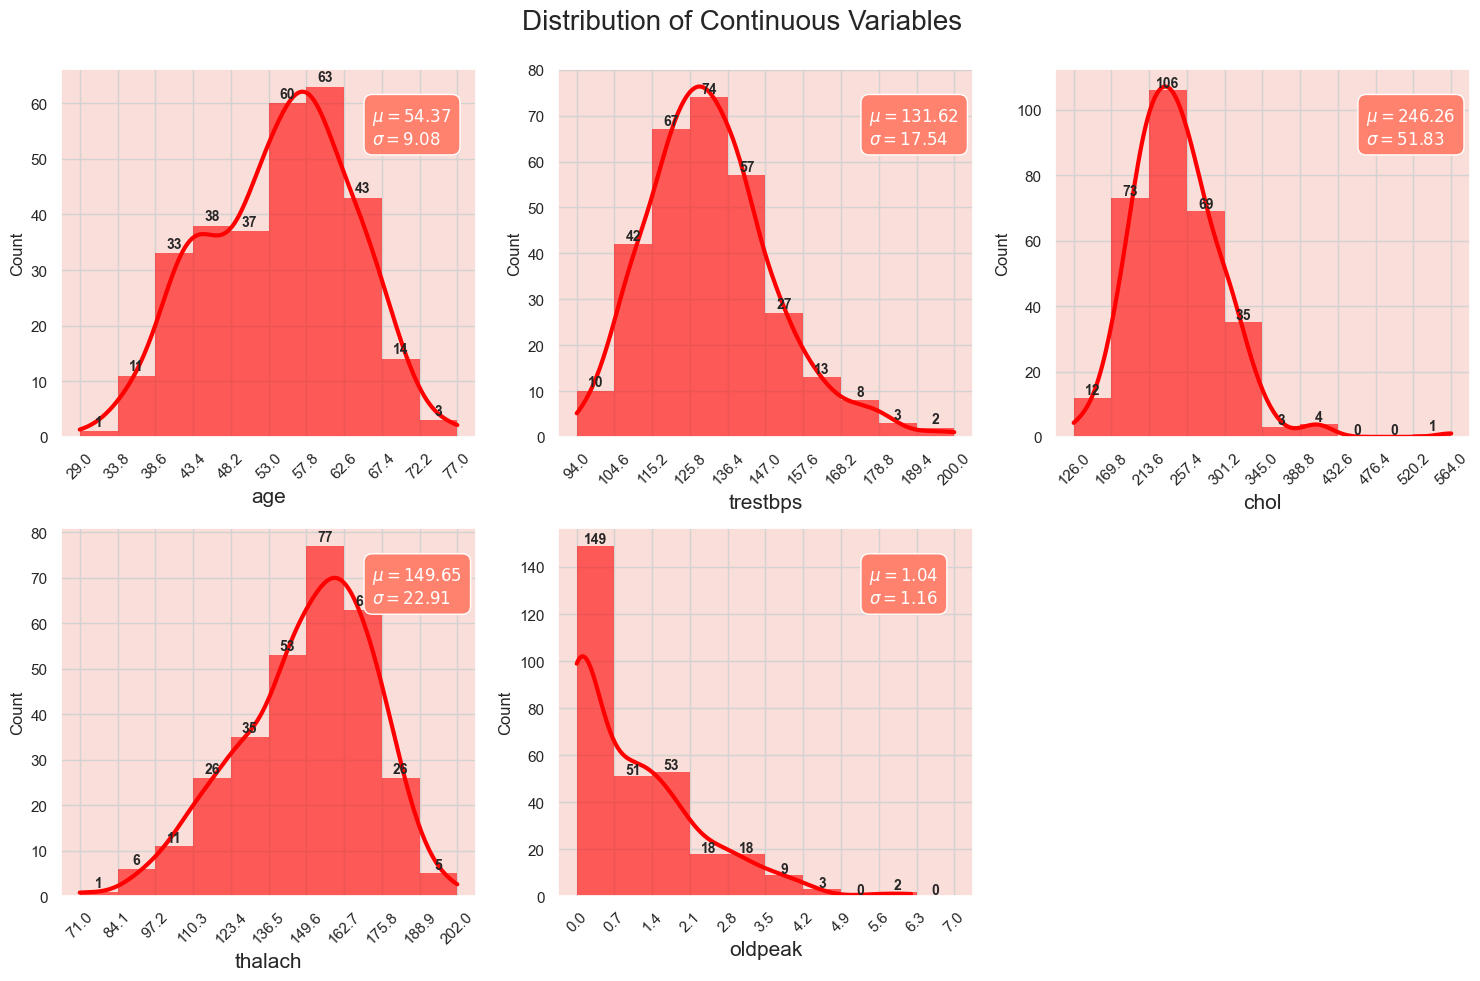

In [14]:
df_continuous = df[continuous_features]

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))


for i, col in enumerate(df_continuous.columns):
    x = i // 3
    y = i % 3
    values, bin_edges = np.histogram(df_continuous[col], 
                                     range=(np.floor(df_continuous[col].min()), np.ceil(df_continuous[col].max())))
    
    graph = sns.histplot(data=df_continuous, x=col, bins=bin_edges, kde=True, ax=ax[x, y],
                         edgecolor='none', color='red', alpha=0.6, line_kws={'lw': 3})
    ax[x, y].set_xlabel(col, fontsize=15)
    ax[x, y].set_ylabel('Count', fontsize=12)
    ax[x, y].set_xticks(np.round(bin_edges, 1))
    ax[x, y].set_xticklabels(ax[x, y].get_xticks(), rotation=45)
    ax[x, y].grid(color='lightgrey')
    
    for j, p in enumerate(graph.patches):
        ax[x, y].annotate('{}'.format(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height() + 1),
                          ha='center', fontsize=10, fontweight="bold")
    
    textstr = '\n'.join((
        r'$\mu=%.2f$' % df_continuous[col].mean(),
        r'$\sigma=%.2f$' % df_continuous[col].std()
    ))
    ax[x, y].text(0.75, 0.9, textstr, transform=ax[x, y].transAxes, fontsize=12, verticalalignment='top',
                  color='white', bbox=dict(boxstyle='round', facecolor='#ff826e', edgecolor='white', pad=0.5))

ax[1,2].axis('off')
plt.suptitle('Distribution of Continuous Variables', fontsize=20)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

vaiable univarite analysis 


In [15]:
categorical_features = df.columns.difference(continuous_features)
df_categorical = df[categorical_features]

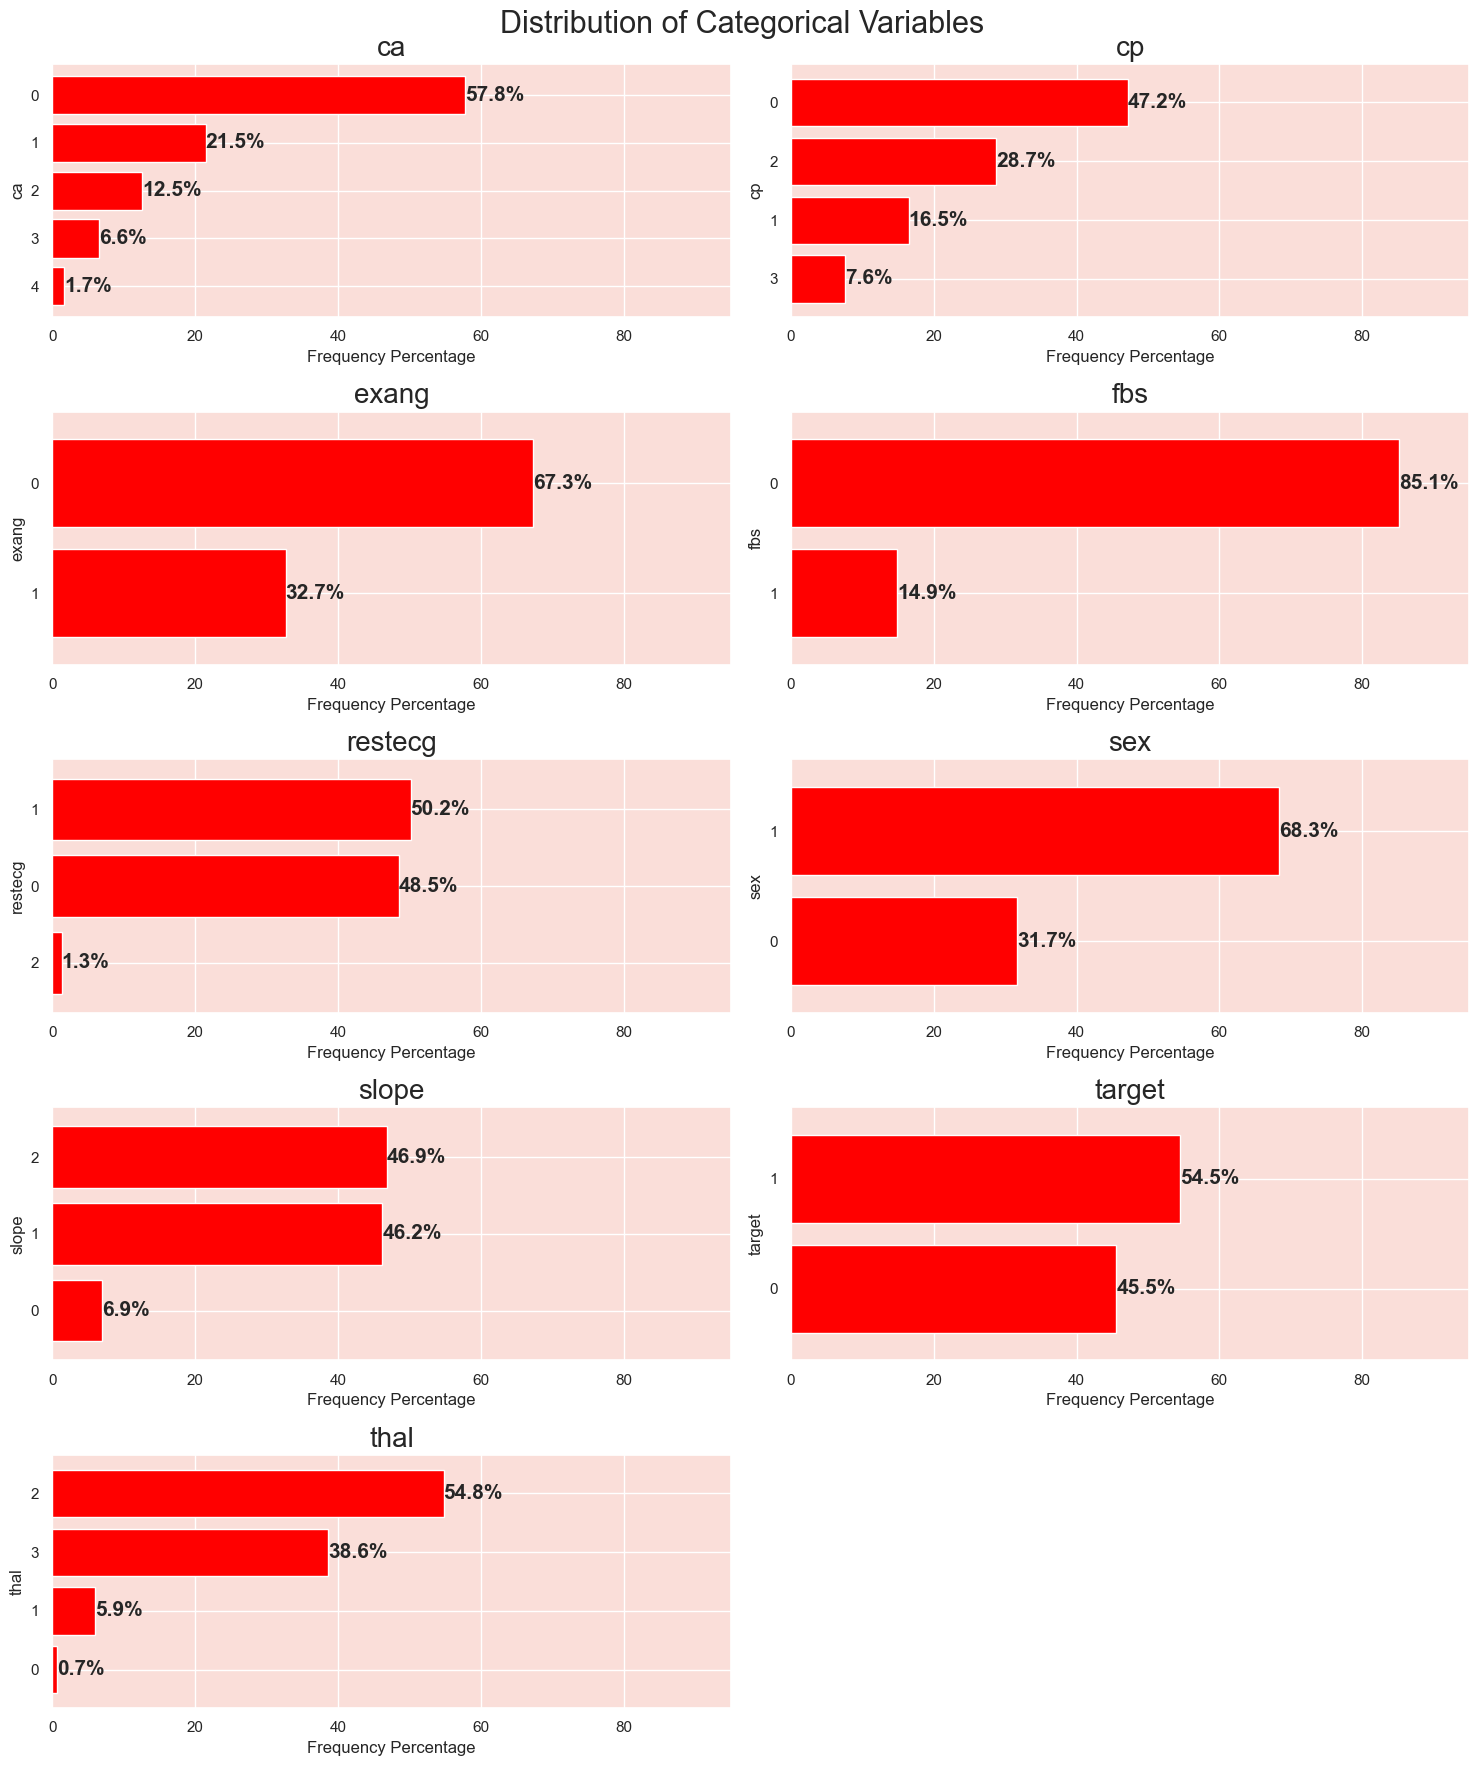

In [16]:
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(15, 18))

# Loop to plot bar charts for each categorical feature in the 4x2 layout
for i, col in enumerate(categorical_features):
    row = i // 2
    col_idx = i % 2
    
    # Calculate frequency percentages
    value_counts = df[col].value_counts(normalize=True).mul(100).sort_values()
    
    # Plot bar chart
    value_counts.plot(kind='barh', ax=ax[row, col_idx], width=0.8, color='red')
    
    # Add frequency percentages to the bars
    for index, value in enumerate(value_counts):
        ax[row, col_idx].text(value, index, str(round(value, 1)) + '%', fontsize=15, weight='bold', va='center')
    
    ax[row, col_idx].set_xlim([0, 95])
    ax[row, col_idx].set_xlabel('Frequency Percentage', fontsize=12)
    ax[row, col_idx].set_title(f'{col}', fontsize=20)

ax[4,1].axis('off')
plt.suptitle('Distribution of Categorical Variables', fontsize=22)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [17]:
## missing value find

df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [18]:
continuous_features

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [19]:
# the outllier treatment 

Q1 = df[continuous_features].quantile(0.25)
Q3 = df[continuous_features].quantile(0.75)
IQR = Q3-Q1
outliers_count_specified = ((df[continuous_features]< (Q1 - 1.5*IQR)) | (df[continuous_features]>(Q3+1.5*IQR))).sum()

outliers_count_specified

age         0
trestbps    9
chol        5
thalach     1
oldpeak     5
dtype: int64

In [20]:
# implementing one hot encoding on the specified categoricqal features 
df_encoded = pd.get_dummies(df,columns=['cp','restecg', 'thal'], drop_first = True)

features_to_convert = ['sex','fbs','exang','slope','ca','target']
for feature in features_to_convert :
    df_encoded[feature]= df_encoded[feature].astype(int)

df_encoded.dtypes

age            int64
sex            int64
trestbps       int64
chol           int64
fbs            int64
thalach        int64
exang          int64
oldpeak      float64
slope          int64
ca             int64
target         int64
cp_1            bool
cp_2            bool
cp_3            bool
restecg_1       bool
restecg_2       bool
thal_1          bool
thal_2          bool
thal_3          bool
dtype: object

In [21]:
df_encoded.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,target,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
0,63,1,145,233,1,150,0,2.3,0,0,1,False,False,True,False,False,True,False,False
1,37,1,130,250,0,187,0,3.5,0,0,1,False,True,False,True,False,False,True,False
2,41,0,130,204,0,172,0,1.4,2,0,1,True,False,False,False,False,False,True,False
3,56,1,120,236,0,178,0,0.8,2,0,1,True,False,False,True,False,False,True,False
4,57,0,120,354,0,163,1,0.6,2,0,1,False,False,False,True,False,False,True,False


In [22]:
# define our x and y
X = df_encoded.drop('target',axis = 1)
y = df_encoded['target']

In [23]:
# spliting train and test 
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state =0, stratify=y)

In [24]:
X_train.shape , X_test.shape

((242, 18), (61, 18))

In [25]:
continuous_features

['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

In [26]:
X_train['oldpeak'] = X_train['oldpeak']+0.001
X_test['oldpeak']= X_test['oldpeak'] + 0.001

In [27]:
X_train.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
269,56,1,130,283,1,103,1,1.601,0,0,False,False,False,False,False,False,False,True
191,58,1,128,216,0,131,1,2.201,1,3,False,False,False,False,False,False,False,True
15,50,0,120,219,0,158,0,1.601,1,0,False,True,False,True,False,False,True,False
224,54,1,110,239,0,126,1,2.801,1,1,False,False,False,True,False,False,False,True
250,51,1,140,298,0,122,1,4.201,1,3,False,False,False,True,False,False,False,True


In [28]:
bool_cols = X_train.select_dtypes(include='bool').columns

X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

In [29]:
X_train.head()

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
269,56,1,130,283,1,103,1,1.601,0,0,0,0,0,0,0,0,0,1
191,58,1,128,216,0,131,1,2.201,1,3,0,0,0,0,0,0,0,1
15,50,0,120,219,0,158,0,1.601,1,0,0,1,0,1,0,0,1,0
224,54,1,110,239,0,126,1,2.801,1,1,0,0,0,1,0,0,0,1
250,51,1,140,298,0,122,1,4.201,1,3,0,0,0,1,0,0,0,1


descison tree model

In [30]:
dt_base = DecisionTreeClassifier(random_state=0)

In [31]:
def tune_clf_hyperparameters(clf, param_grid, X_train, y_train,
                             scoring='recall', n_splits=3):

    # creating cross-validation object
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=0
    )

    # creating gridsearchcv model
    clf_grid = GridSearchCV(
        clf,
        param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    # fitting
    clf_grid.fit(X_train, y_train)

    # best parameter
    best_hyperparameters = clf_grid.best_params_

    # return best estimator
    return clf_grid.best_estimator_, best_hyperparameters

In [32]:
param_grid_dt={
    'criterion':['gini','entropy'],
    'max_depth':[2,3],
    'min_samples_split':[2,3,4],
    'min_samples_leaf':[1,2]
}

In [33]:
#call ythe fucntion hyperparamter 
best_dt,best_dt_hyperparams= tune_clf_hyperparameters(dt_base,param_grid_dt,X_train,y_train)

In [34]:
print('DT Optimal Hyperparameters: \n', best_dt_hyperparams)

DT Optimal Hyperparameters: 
 {'criterion': 'entropy', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}


DT evealuation model 
lets evaluate teh model

In [35]:
## evalaution
print(classification_report(y_train,best_dt.predict(X_train)))

              precision    recall  f1-score   support

           0       0.73      0.75      0.74       110
           1       0.78      0.77      0.78       132

    accuracy                           0.76       242
   macro avg       0.76      0.76      0.76       242
weighted avg       0.76      0.76      0.76       242



In [36]:
print(classification_report(y_test,best_dt.predict(X_test)))

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        28
           1       0.78      0.85      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



In [89]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluates the performance of a trained model on test data using various metrics.
    """
    # Make predictions
    y_pred = model.predict(X_test)
    
    
    report = classification_report(y_test, y_pred, output_dict=True)
    
    
    metrics = {
        "precision_0": report["0"]["precision"],
        "precision_1": report["1"]["precision"],
        "recall_0": report["0"]["recall"],
        "recall_1": report["1"]["recall"],
        "f1_0": report["0"]["f1-score"],
        "f1_1": report["1"]["f1-score"],
        "macro_avg_precision": report["macro avg"]["precision"],
        "macro_avg_recall": report["macro avg"]["recall"],
        "macro_avg_f1": report["macro avg"]["f1-score"],
        "accuracy": accuracy_score(y_test, y_pred)
    }
    
    # Convert dictionary to dataframe
    df = pd.DataFrame(metrics, index=[model_name]).round(2)
    
    return df

In [90]:
dt_evaluation = evaluate_model(best_dt, X_test, y_test, 'DT')
dt_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
DT,0.8,0.78,0.71,0.85,0.75,0.81,0.79,0.78,0.78,0.79


Rabdom Forest model 
our second model to seee if its give better accuracy . 

In [54]:
rf_base = RandomForestClassifier(random_state=0)

In [55]:
param_grid_rf = {
    'n_estimators': [10, 30, 50, 70, 100],
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4],
    'min_samples_split': [2, 3, 4, 5],
    'min_samples_leaf': [1, 2, 3],
    'bootstrap': [True, False]
}

In [57]:
best_rf, best_rf_hyperparams = tune_clf_hyperparameters(rf_base, param_grid_rf, X_train, y_train)

print('RF Optimal Hyperparameters: \n', best_rf_hyperparams)

RF Optimal Hyperparameters: 
 {'bootstrap': True, 'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 30}


In [58]:
print(classification_report(y_train, best_rf.predict(X_train)))

              precision    recall  f1-score   support

           0       0.83      0.78      0.81       110
           1       0.83      0.87      0.85       132

    accuracy                           0.83       242
   macro avg       0.83      0.83      0.83       242
weighted avg       0.83      0.83      0.83       242



In [60]:
print(classification_report(y_test, best_rf.predict(X_test)))

              precision    recall  f1-score   support

           0       0.85      0.79      0.81        28
           1       0.83      0.88      0.85        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



In [92]:
rf_evaluation = evaluate_model(best_rf, X_test, y_test, 'RF')
rf_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
RF,0.85,0.83,0.79,0.88,0.81,0.85,0.84,0.83,0.83,0.84


KNN clasiifier 
the third model we are gonna perform to get the accuracy 

In [63]:
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
]
)

In [66]:
knn_param_grid = {
    'knn__n_neighbors': list(range(1, 12)),
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2] 
}

In [67]:
best_knn,best_knn_hyperparams = tune_clf_hyperparameters(knn_pipeline,knn_param_grid,X_train, y_train)
print("KNN Optimal hyperparametr", best_knn_hyperparams)

KNN Optimal hyperparametr {'knn__n_neighbors': 10, 'knn__p': 1, 'knn__weights': 'distance'}


In [69]:
print(classification_report(y_train,best_knn.predict(X_train)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       110
           1       1.00      1.00      1.00       132

    accuracy                           1.00       242
   macro avg       1.00      1.00      1.00       242
weighted avg       1.00      1.00      1.00       242



In [70]:
print(classification_report(y_test,best_knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.82      0.82      0.82        28
           1       0.85      0.85      0.85        33

    accuracy                           0.84        61
   macro avg       0.83      0.83      0.83        61
weighted avg       0.84      0.84      0.84        61



In [93]:
knn_evaluation = evaluate_model(best_knn, X_test, y_test, 'KNN')
knn_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
KNN,0.82,0.85,0.82,0.85,0.82,0.85,0.83,0.83,0.83,0.84


SVM model
the fourth model to check the bestter accuarcy performing model 

In [83]:
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True)) 
])

In [99]:
param_grid_svm = {
    'svm__C': [0.0011, 0.005, 0.01, 0.05, 0.1, 1, 10, 20],
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__gamma': ['scale', 'auto', 0.1, 0.5, 1, 5],  
    'svm__degree': [2, 3, 4]
}

In [100]:
best_svm, best_svm_hyperparams = tune_clf_hyperparameters(svm_pipeline, param_grid_svm, X_train, y_train)
print('SVM Optimal Hyperparameters: \n', best_svm_hyperparams)

SVM Optimal Hyperparameters: 
 {'svm__C': 0.0011, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}


In [86]:
print(classification_report(y_train,best_svm.predict(X_train)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       110
           1       0.55      1.00      0.71       132

    accuracy                           0.55       242
   macro avg       0.27      0.50      0.35       242
weighted avg       0.30      0.55      0.39       242



In [87]:
print(classification_report(y_test,best_svm.predict(X_test)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        28
           1       0.54      1.00      0.70        33

    accuracy                           0.54        61
   macro avg       0.27      0.50      0.35        61
weighted avg       0.29      0.54      0.38        61



In [94]:
svm_evaluation = evaluate_model(best_svm,X_train,y_train,'SVM')
svm_evaluation

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
SVM,0.0,0.55,0.0,1.0,0.0,0.71,0.27,0.5,0.35,0.55


Now we will evaluate all model .
basic of accuarcy , recall , f1 score .
to detremine which has given the best result out of all 

In [98]:
all_evalaution = [dt_evaluation,rf_evaluation,knn_evaluation,svm_evaluation]
results = pd.concat(all_evalaution)

results = results.sort_values(by='recall_1', ascending=False).round(2)
results

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
SVM,0.00,0.55,0.00,1.00,0.00,0.71,0.27,0.50,0.35,0.55
RF,0.85,0.83,0.79,0.88,0.81,0.85,0.84,0.83,0.83,0.84
DT,0.80,0.78,0.71,0.85,0.75,0.81,0.79,0.78,0.78,0.79
KNN,0.82,0.85,0.82,0.85,0.82,0.85,0.83,0.83,0.83,0.84


__BY all metrics every model has perform its best on serval metrics.
The svm has the highest recall value . but i think there is data leakage in the dataset on the evaluation metrics 
because all patients are identife with 100 % metrics which is close to impossible .

personal note - I would love some advice on ehich metrics i can perform better . 